# **Assignment 1 Machine Learning**
Name: Justin Christian Kenan

Student ID: 2802399463

Class: LC01

Libraries

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

Dataset

In [60]:
dataset = pd.read_csv('covid_19_indonesia_time_series_all.csv')
dataset.head(10)

,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,...,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,3/1/2020,ID-JK,DKI Jakarta,2,0,0,2,39,20,75,...,-6.204699,0.18,3.60,0.00,1.84,0.18,51.28%,192.31%,NaN,NaN
1,3/2/2020,ID-JK,DKI Jakarta,2,0,0,2,41,20,75,...,-6.204699,0.18,3.78,0.00,1.84,0.18,48.78%,182.93%,1.0,1.0
2,3/2/2020,IDN,Indonesia,2,0,0,2,2,0,0,...,-0.789275,0.01,0.01,0.00,0.00,0.00,0.00%,0.00%,NaN,NaN
3,3/2/2020,ID-RI,Riau,1,0,0,1,1,0,1,...,0.511648,0.16,0.16,0.00,0.00,0.00,0.00%,100.00%,NaN,NaN
4,3/3/2020,ID-JK,DKI Jakarta,2,0,0,2,43,20,75,...,-6.204699,0.18,3.96,0.00,1.84,0.18,46.51%,174.42%,1.0,1.0
5,3/3/2020,IDN,Indonesia,0,0,0,0,2,0,0,...,-0.789275,0.00,0.01,0.00,0.00,0.00,0.00%,0.00%,0.0,1.0
6,3/3/2020,ID-JB,Jawa Barat,1,1,0,0,1,1,60,...,-6.920432,0.02,0.02,0.02,0.02,0.00,100.00%,6000.00%,NaN,NaN
7,3/3/2020,ID-RI,Riau,0,0,0,0,1,0,1,...,0.511648,0.00,0.16,0.00,0.00,0.00,0.00%,100.00%,0.0,1.0
8,3/4/2020,ID-JK,DKI Jakarta,2,0,0,2,45,20,75,...,-6.204699,0.18,4.15,0.00,1.84,0.18,44.44%,166.67%,1.0,1.0
9,3/4/2020,IDN,Indonesia,0,0,0,0,2,0,0,...,-0.789275,0.00,0.01,0.00,0.00,0.00,0.00%,0.00%,1.0,1.0


# Exploratory Data Analysis (EDA)

Dataset Structure

In [61]:
# Number of rows and columns in the dataset
dataset.shape

(31822, 38)

In [62]:
# Data types of each column
dataset.dtypes

Date                            object
Location ISO Code               object
Location                        object
New Cases                        int64
New Deaths                       int64
New Recovered                    int64
New Active Cases                 int64
Total Cases                      int64
Total Deaths                     int64
Total Recovered                  int64
Total Active Cases               int64
Location Level                  object
City or Regency                float64
Province                        object
Country                         object
Continent                       object
Island                          object
Time Zone                       object
Special Status                  object
Total Regencies                  int64
Total Cities                   float64
Total Districts                  int64
Total Urban Villages           float64
Total Rural Villages           float64
Area (km2)                       int64
Population               

In [63]:
# Descriptive statistical analysis on dataset
dataset.describe()

,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,Total Active Cases,City or Regency,Total Regencies,...,Population Density,Longitude,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Growth Factor of New Cases,Growth Factor of New Deaths
count,31822.000000,31822.000000,31822.000000,31822.000000,3.182200e+04,31822.000000,3.182200e+04,31822.000000,0.0,31822.000000,...,31822.000000,31822.000000,31822.000000,31822.000000,31822.000000,31822.000000,31822.000000,31822.000000,29883.000000,28375.000000
mean,402.311388,9.920652,390.398498,1.992238,1.594500e+05,4564.753221,1.492615e+05,5623.782415,NaN,24.027277,...,738.894928,113.700478,-2.725681,28.133292,11485.038800,0.640308,289.633640,28.963329,1.326795,1.033834
std,2320.629838,64.139080,2199.878802,1219.513355,6.264435e+05,17693.731369,5.958536e+05,28537.412305,NaN,68.359734,...,2729.431626,9.862068,3.608065,74.309710,16477.385479,1.933016,363.428724,36.342881,2.679379,1.351755
min,0.000000,0.000000,0.000000,-29938.000000,1.000000e+00,0.000000,0.000000e+00,-2343.000000,NaN,1.000000,...,8.590000,96.910522,-8.682205,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,2.000000,-12.000000,5.223250e+03,128.000000,3.913500e+03,80.000000,NaN,7.000000,...,47.790000,106.109004,-6.204699,0.830000,1291.367500,0.000000,38.862500,3.890000,0.650000,0.750000
50%,27.000000,0.000000,20.000000,0.000000,2.359650e+04,565.500000,2.102750e+04,557.000000,NaN,11.000000,...,103.840000,113.417654,-2.461746,5.710000,6804.285000,0.000000,158.415000,15.840000,1.000000,1.000000
75%,130.000000,3.000000,123.000000,19.000000,6.992775e+04,2189.000000,6.414200e+04,2279.000000,NaN,18.000000,...,262.700000,121.201093,0.212037,22.290000,14557.360000,0.540000,389.910000,38.990000,1.310000,1.000000
max,64718.000000,2069.000000,61361.000000,39165.000000,6.405044e+06,157876.000000,6.218708e+06,586113.000000,NaN,416.000000,...,16334.310000,138.696030,4.225615,1459.040000,130231.620000,63.800000,1632.600000,163.260000,175.000000,134.500000


Checking Missing Values

In [64]:
dataset.isnull().sum().sort_values(ascending=False)

City or Regency                31822
Special Status                 27264
Growth Factor of New Deaths     3447
Growth Factor of New Cases      1939
Total Rural Villages             929
Island                           929
Time Zone                        929
Province                         929
Total Urban Villages             904
Total Cities                     901
Location ISO Code                  0
Date                               0
New Cases                          0
Location                           0
New Recovered                      0
New Deaths                         0
Total Deaths                       0
Total Recovered                    0
Total Active Cases                 0
Location Level                     0
New Active Cases                   0
Total Cases                        0
Total Districts                    0
Total Regencies                    0
Continent                          0
Country                            0
Population Density                 0
L

Histogram

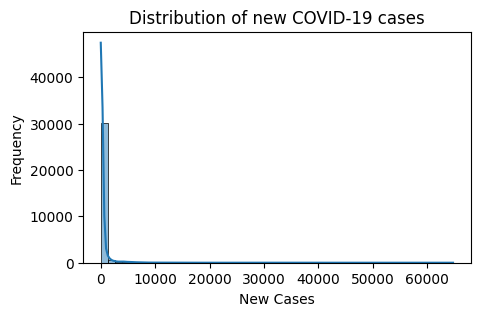

In [65]:
plt.figure(figsize=(5,3))
plt.title("Distribution of new COVID-19 cases")
plt.xlabel("New Cases")
plt.ylabel("Frequency")
sns.histplot(dataset["New Cases"], bins=50, kde=True)
plt.show()

The distribution of new COVID-19 cases is showed skewed to the right. Most of the data has a low number of cases, but there are some very high spikes in cases.

Box Plot

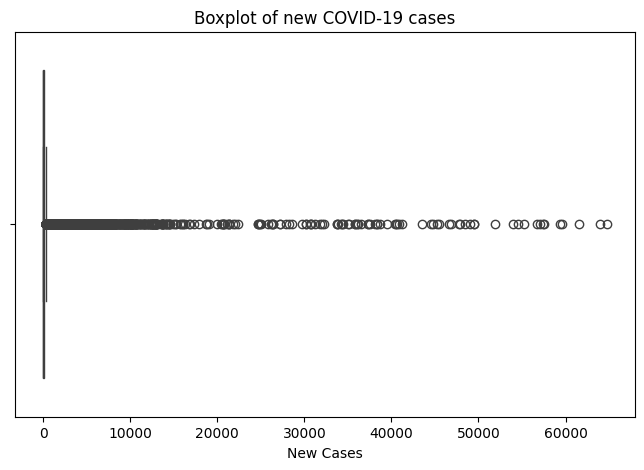

In [66]:
plt.figure(figsize=(8, 5))
plt.title("Boxplot of new COVID-19 cases")
sns.boxplot(x=dataset["New Cases"])
plt.show()

The boxplot shows a large number of outliers in the new COVID-19 cases feature. This occurs because the dataset contains several days with very high spikes in cases compared to the rest of the data.

Scatter Plot

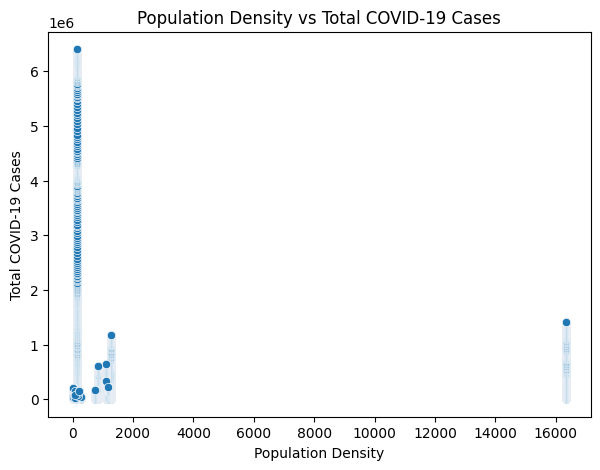

In [67]:
plt.figure(figsize=(7, 5))
plt.title("Population Density vs Total COVID-19 Cases")
plt.xlabel("Population Density")
plt.ylabel("Total COVID-19 Cases")
sns.scatterplot(x="Population Density", y="Total Cases", data=dataset)
plt.show()

Scatter Plot shows many observations share the same population density values with the result vertical cluster of points, because the dataset records multiple times entries for the same provinces with population density remains constant while the total number of COVID-19 cases changes over time.

Interesting Insight
1. There several significant COVID-19 cases during the pandemic, so the Distribution of new cases shows an abnormal pattern or skewed.
2. There's a positive correlation between Population density and Total cases, it's mean shows that areas with higher population density have a greater potential for the spread of the COVID-19 virus.
3. The increase in the number or COVID-19 cases followed by an increase in the number of the deaths.

# Data Preprocessing

Handling missing values

The strategy for filling in missing data in the dataset is using mean imputation to maintain data distribution without deleting too many rows of data.

In [68]:
dataset = dataset.fillna(dataset.mean(numeric_only=True))

Encoding categorical features using Label Encoder  

Label Encoding used to transform categorical featurres into numerical values with assigns a unique integer into each category in a feature, also this method simple and efficient which that suitable for categorical variables with unique categories (provinces, island, location level).

In [69]:
label_encoder = LabelEncoder()

dataset['Province'] = label_encoder.fit_transform(dataset['Province'].astype(str))
dataset['Island'] = label_encoder.fit_transform(dataset['Island'].astype(str))
dataset['Location Level'] = label_encoder.fit_transform(dataset['Location Level'].astype(str))

Normalize (feature scalling)

StandarScaler transforms the data, which has a standard deviation of 1 and mean of 0. The numerical features in the dataset has different ranges so that normalize will improve the performance of machine learning algorithms that sensitive to feature scalling.

In [70]:
scaler = StandardScaler()
numeric_cols = ['Population', 'Population Density', 'New Cases', 'Total Cases']
dataset[numeric_cols] = scaler.fit_transform(dataset[numeric_cols])

Result

In [ ]:
dataset.head(15)

,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,...,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,3/1/2020,ID-JK,DKI Jakarta,-0.172504,0,0,2,-0.254474,20,75,...,-6.204699,0.18,3.60,0.00,1.84,0.18,51.28%,192.31%,1.326795,1.033834
1,3/2/2020,ID-JK,DKI Jakarta,-0.172504,0,0,2,-0.254471,20,75,...,-6.204699,0.18,3.78,0.00,1.84,0.18,48.78%,182.93%,1.000000,1.000000
2,3/2/2020,IDN,Indonesia,-0.172504,0,0,2,-0.254533,0,0,...,-0.789275,0.01,0.01,0.00,0.00,0.00,0.00%,0.00%,1.326795,1.033834
3,3/2/2020,ID-RI,Riau,-0.172935,0,0,1,-0.254535,0,1,...,0.511648,0.16,0.16,0.00,0.00,0.00,0.00%,100.00%,1.326795,1.033834
4,3/3/2020,ID-JK,DKI Jakarta,-0.172504,0,0,2,-0.254468,20,75,...,-6.204699,0.18,3.96,0.00,1.84,0.18,46.51%,174.42%,1.000000,1.000000
5,3/3/2020,IDN,Indonesia,-0.173366,0,0,0,-0.254533,0,0,...,-0.789275,0.00,0.01,0.00,0.00,0.00,0.00%,0.00%,0.000000,1.000000
6,3/3/2020,ID-JB,Jawa Barat,-0.172935,1,0,0,-0.254535,1,60,...,-6.920432,0.02,0.02,0.02,0.02,0.00,100.00%,6000.00%,1.326795,1.033834
7,3/3/2020,ID-RI,Riau,-0.173366,0,0,0,-0.254535,0,1,...,0.511648,0.00,0.16,0.00,0.00,0.00,0.00%,100.00%,0.000000,1.000000
8,3/4/2020,ID-JK,DKI Jakarta,-0.172504,0,0,2,-0.254464,20,75,...,-6.204699,0.18,4.15,0.00,1.84,0.18,44.44%,166.67%,1.000000,1.000000
9,3/4/2020,IDN,Indonesia,-0.173366,0,0,0,-0.254533,0,0,...,-0.789275,0.00,0.01,0.00,0.00,0.00,0.00%,0.00%,1.000000,1.000000
